In [13]:
%pip install powerlaw
%pip install adjustText

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Loading data...
Data loaded. Total action tokens processed: 1442182

--- Processing Zipf's law ---
Zipf exponent (α): 2.2149


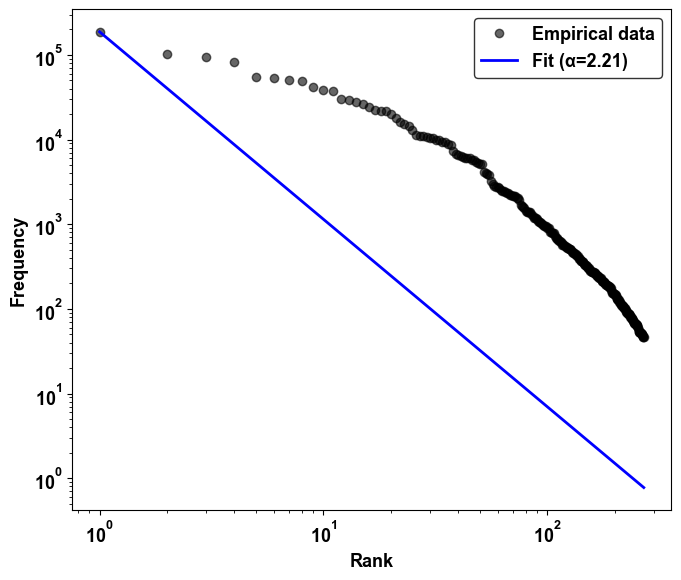

In [14]:

# =============================================================================
# CELL 0 — Zipf / Heaps / Taylor  (global)
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import powerlaw

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

print("Loading data...")
df_actions_raw = pd.read_excel("Datasets/RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv")
df_merged = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')
print(f"Data loaded. Total action tokens processed: {len(df_merged)}")

# ── ZIPF'S LAW ──────────────────────────────────────────────────────────────
print("\n--- Processing Zipf's law ---")
action_counts = df_merged['action_id'].value_counts()
frequencies = action_counts.values
ranks = np.arange(1, len(frequencies) + 1)
fit = powerlaw.Fit(frequencies, discrete=True, verbose=False)
alpha_zipf = 1.0 / (fit.alpha - 1.0)
print(f"Zipf exponent (α): {alpha_zipf:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.loglog(ranks, frequencies, marker='o', linestyle='none', alpha=0.6, color='black', label='Empirical data')
ax.plot(ranks, frequencies[0] * (ranks ** -alpha_zipf), color='blue', linestyle='-', linewidth=2, label=f'Fit (α={alpha_zipf:.2f})')
ax.set_xlabel("Rank", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")
format_axes(ax)
plt.tight_layout()
plt.savefig("zipf_law_action_frequency.png", dpi=300)
plt.savefig("zipf_law_action_frequency.tif", dpi=300)
plt.show()



--- Processing Heaps' law ---
Heaps exponent (β): 0.3596  (fitted over first 808 recipes, pre-saturation)


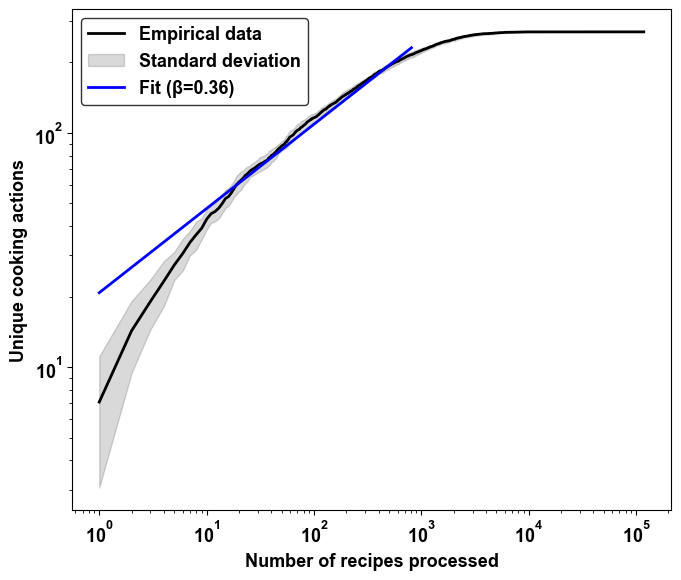

In [ ]:

# ── HEAPS' LAW ───────────────────────────────────────────────────────────────
# FIX: with only 270 unique actions, vocabulary saturates quickly.
# Fit only the pre-saturation growth region (up to 80% of V_max).

print("\n--- Processing Heaps' law ---")
recipe_groups = df_merged.groupby('recipe_no')['action_id'].apply(set).tolist()
num_simulations = 10
num_recipes = len(recipe_groups)
v_history = np.zeros((num_simulations, num_recipes))

for i in range(num_simulations):
    shuffled = np.random.permutation(recipe_groups)
    unique_actions = set()
    current_v = []
    for r in shuffled:
        unique_actions.update(r)
        current_v.append(len(unique_actions))
    v_history[i, :] = current_v

x_recipes = np.arange(1, num_recipes + 1)
y_mean = np.mean(v_history, axis=0)
y_std  = np.std(v_history, axis=0)

# Fit only the pre-saturation growth region (up to 80% of V_max)
v_max = y_mean[-1]
sat_idx = int(np.argmax(y_mean >= 0.80 * v_max))
sat_idx = max(sat_idx, 10)   # need at least 10 points for a regression

x_fit = x_recipes[:sat_idx]
y_fit = y_mean[:sat_idx]
beta, intercept = np.polyfit(np.log(x_fit), np.log(y_fit), 1)
K_value = np.exp(intercept)
print(f"Heaps exponent (β): {beta:.4f}  (fitted over first {sat_idx} recipes, pre-saturation)")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(x_recipes, y_mean, color='black', linewidth=2, label='Empirical data')
ax.fill_between(x_recipes, y_mean - y_std, y_mean + y_std, color='black', alpha=0.15, label='Standard deviation')
ax.plot(x_fit, K_value * (x_fit ** beta), color='blue', linestyle='-', linewidth=2, label=f'Fit (β={beta:.2f})')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Number of recipes processed", fontweight="bold")
ax.set_ylabel("Unique cooking actions", fontweight="bold")
format_axes(ax)
plt.tight_layout()
plt.savefig("heaps_law_action_vocabulary_growth.png", dpi=300)
plt.savefig("heaps_law_action_vocabulary_growth.tif", dpi=300)
plt.show()




--- Processing Taylor's law ---
Taylor slope: 0.9430


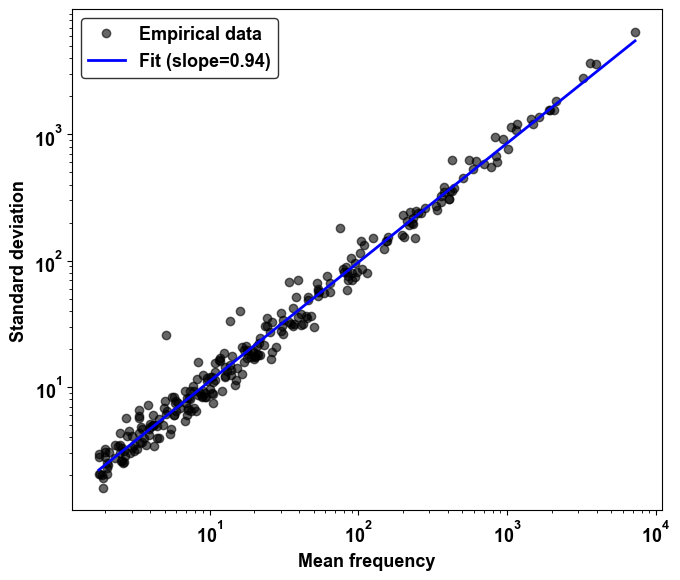

In [16]:

# ── TAYLOR'S LAW ─────────────────────────────────────────────────────────────
print("\n--- Processing Taylor's law ---")
cuisine_counts = pd.crosstab(df_merged['action_id'], df_merged['Cuisine'])
mu_vec    = cuisine_counts.mean(axis=1)
sigma_vec = cuisine_counts.std(axis=1)
mask = (mu_vec > 0) & (sigma_vec > 0)
mu_vec    = mu_vec[mask]
sigma_vec = sigma_vec[mask]
slope, intercept = np.polyfit(np.log(mu_vec), np.log(sigma_vec), 1)
print(f"Taylor slope: {slope:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.loglog(mu_vec, sigma_vec, marker='o', linestyle='none', alpha=0.6, color='black', label='Empirical data')
fit_x = np.linspace(min(mu_vec), max(mu_vec), 100)
ax.plot(fit_x, np.exp(intercept) * (fit_x ** slope), color='blue', linestyle='-', linewidth=2, label=f'Fit (slope={slope:.2f})')
ax.set_xlabel("Mean frequency", fontweight="bold")
ax.set_ylabel("Standard deviation", fontweight="bold")
format_axes(ax)
plt.tight_layout()
plt.savefig("taylors_law_action_fluctuation_scaling.png", dpi=300)
plt.savefig("taylors_law_action_fluctuation_scaling.tif", dpi=300)
plt.show()



Fitted parameters: a=6.1733, b=-0.0537, c=-0.0027


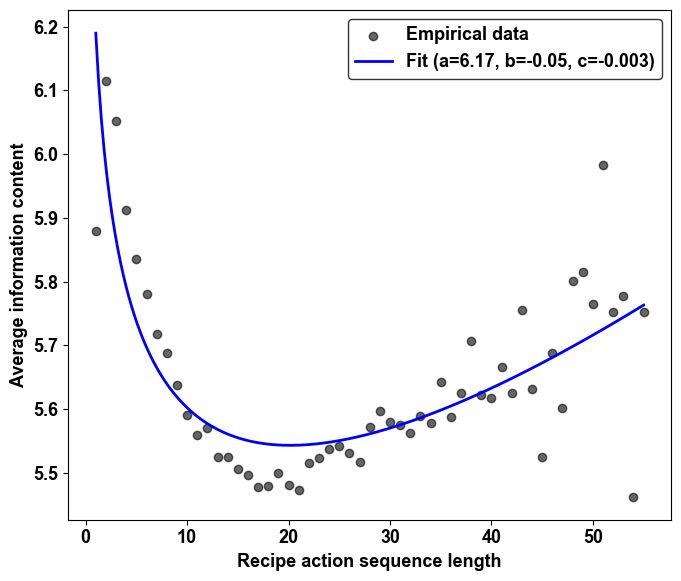

In [17]:

# =============================================================================
# CELL 1 — Menzerath-Altmann (global, basic fit)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

df_actions_raw = pd.read_excel("Datasets/RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})

action_counts = df_actions['action_id'].value_counts()
total_tokens  = len(df_actions)
action_probs  = action_counts / total_tokens
df_actions['prob'] = df_actions['action_id'].map(action_probs)
df_actions['IC']   = -np.log2(df_actions['prob'])

recipe_stats = df_actions.groupby('recipe_no').agg(x=('action_id', 'count'), y=('IC', 'mean'))
ma_data = recipe_stats.groupby('x')['y'].mean().reset_index()
valid_lengths = recipe_stats['x'].value_counts()
valid_lengths = valid_lengths[valid_lengths >= 10].index
ma_data = ma_data[ma_data['x'].isin(valid_lengths)].sort_values('x')
x_data = ma_data['x'].values
y_data = ma_data['y'].values

def menzerath_altmann(x, A, b, c):
    return A * (x ** b) * np.exp(-c * x)

try:
    popt, _ = curve_fit(menzerath_altmann, x_data, y_data, p0=[np.mean(y_data), -0.1, 0.0], maxfev=5000)
    A_fit, b_fit, c_fit = popt
    print(f"Fitted parameters: a={A_fit:.4f}, b={b_fit:.4f}, c={c_fit:.4f}")
    fit_success = True
except Exception as e:
    print(f"Fitting failed: {e}")
    fit_success = False

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x_data, y_data, color='black', alpha=0.6, label='Empirical data')
if fit_success:
    x_line = np.linspace(x_data.min(), x_data.max(), 200)
    ax.plot(x_line, menzerath_altmann(x_line, *popt), color='blue', linewidth=2,
            label=f'Fit (a={A_fit:.2f}, b={b_fit:.2f}, c={c_fit:.3f})')
ax.set_xlabel("Recipe action sequence length", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")
format_axes(ax)
plt.tight_layout()
plt.savefig("menzerath_altmann_action_recipe_structure.png", dpi=300)
plt.savefig("menzerath_altmann_action_recipe_structure.tif", dpi=300)
plt.show()



------------------------------
Corrected α (Head fit): 1.5904
------------------------------


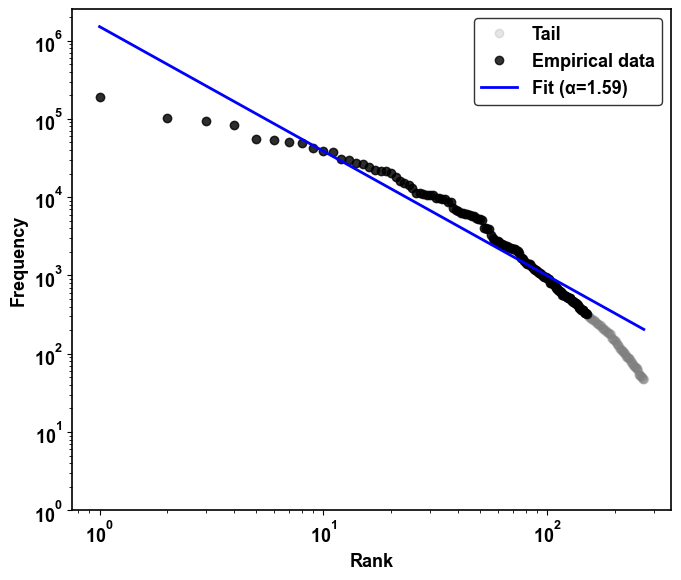

In [18]:

# =============================================================================
# CELL 2 — Zipf head/tail best fit
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

df_actions_raw = pd.read_excel("Datasets/RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})

action_counts = df_actions['action_id'].value_counts()
frequencies   = action_counts.values
ranks         = np.arange(1, len(frequencies) + 1)

# Vocabulary is ~270 actions; fit the head (top 150 ranks)
cutoff_rank = 150
ranks_fit   = ranks[:cutoff_rank]
freqs_fit   = frequencies[:cutoff_rank]
slope, intercept = np.polyfit(np.log(ranks_fit), np.log(freqs_fit), 1)
alpha = -slope
print("-" * 30)
print(f"Corrected α (Head fit): {alpha:.4f}")
print("-" * 30)

fig, ax = plt.subplots(figsize=(7, 6))
ax.loglog(ranks, frequencies, marker='o', linestyle='none', alpha=0.2, color='gray', label='Tail')
ax.loglog(ranks_fit, freqs_fit, marker='o', linestyle='none', alpha=0.8, color='black', markersize=6, label='Empirical data')
fit_x = np.linspace(1, len(ranks), 200)
ax.plot(fit_x, np.exp(intercept) * (fit_x ** -alpha), color='blue', linestyle='-', linewidth=2, label=f'Fit (α={alpha:.2f})')
ax.set_xlabel("Rank", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(bottom=1)
format_axes(ax)
plt.tight_layout()
plt.savefig("zipf_action_head_tail_best_fit.png", dpi=300)
plt.savefig("zipf_action_head_tail_best_fit.tif", dpi=300)
plt.show()



Total unique cooking actions: 270

--- Applying maximum likelihood estimation ---

Results from likelihood method:
  - Optimal cutoff (xmin): 144.0
  - Power law exponent (α): 1.4515
  - Standard error (sigma): 0.0318
  - Calculated rank-frequency slope (β): 2.2149

--- Performing hypothesis testing ---
Log-likelihood ratio (R): -2.6340
p-value: 0.0084
-> Evidence favors the lognormal distribution.


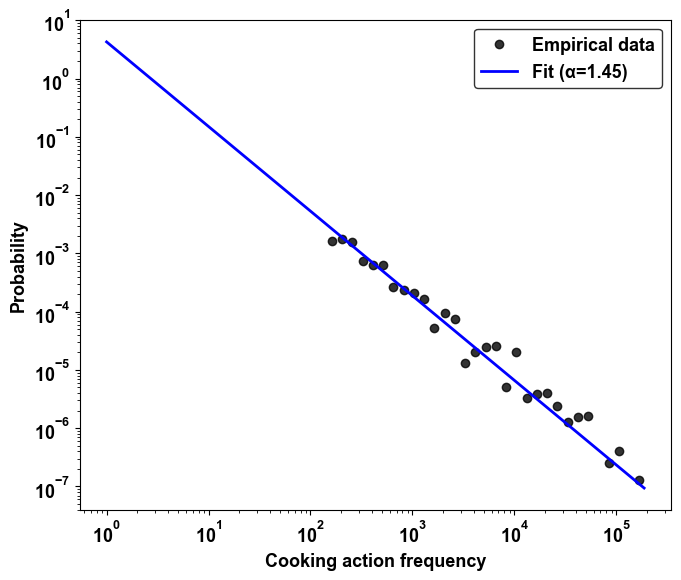

In [19]:

# =============================================================================
# CELL 3 — Zipf MLE (powerlaw) + hypothesis test
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

df_actions_raw = pd.read_excel("Datasets/RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})

action_counts = df_actions['action_id'].value_counts()
data = action_counts.values
print(f"Total unique cooking actions: {len(data)}")
print("\n--- Applying maximum likelihood estimation ---")
fit   = powerlaw.Fit(data, discrete=True, verbose=False)
xmin  = fit.xmin
alpha = fit.alpha
sigma = fit.sigma
print(f"\nResults from likelihood method:")
print(f"  - Optimal cutoff (xmin): {xmin}")
print(f"  - Power law exponent (α): {alpha:.4f}")
print(f"  - Standard error (sigma): {sigma:.4f}")
print(f"  - Calculated rank-frequency slope (β): {1.0/(alpha-1.0):.4f}")

print("\n--- Performing hypothesis testing ---")
R, p = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)
print(f"Log-likelihood ratio (R): {R:.4f}")
print(f"p-value: {p:.4f}")
print("-> Evidence favors the power law distribution." if R > 0 else "-> Evidence favors the lognormal distribution.")

fig, ax = plt.subplots(figsize=(7, 6))
fit.plot_pdf(color='black', linestyle='none', marker='o', alpha=0.8, markersize=6, label='Empirical data', ax=ax)
x_max  = np.max(data)
x_line = np.arange(1, x_max + 1)
y_ref  = fit.power_law.pdf(np.array([xmin]))[0]
ax.plot(x_line, y_ref * (x_line / xmin) ** -alpha, color='blue', linestyle='-', linewidth=2, label=rf'Fit (α={alpha:.2f})')
ax.set_xlabel("Cooking action frequency", fontweight="bold")
ax.set_ylabel("Probability", fontweight="bold")
ax.set_xscale("log")
ax.set_yscale("log")
format_axes(ax)
plt.tight_layout()
plt.savefig("zipf_action_likelihood_method_fit.png", dpi=300)
plt.savefig("zipf_action_likelihood_method_fit.tif", dpi=300)
plt.show()


Loading data...

--- Processing Heaps' law (rigorous fit) ---
Running 10 simulations...
------------------------------
Heaps law parameters (fit over first 824 recipes — pre-saturation):
  Constant (K): 29.6155
  Exponent (β): 0.2999
------------------------------
Model comparison (AIC):
  Heaps law:    2394.06
  Linear model: 4601.23
Result: Evidence favors Heaps law.
------------------------------


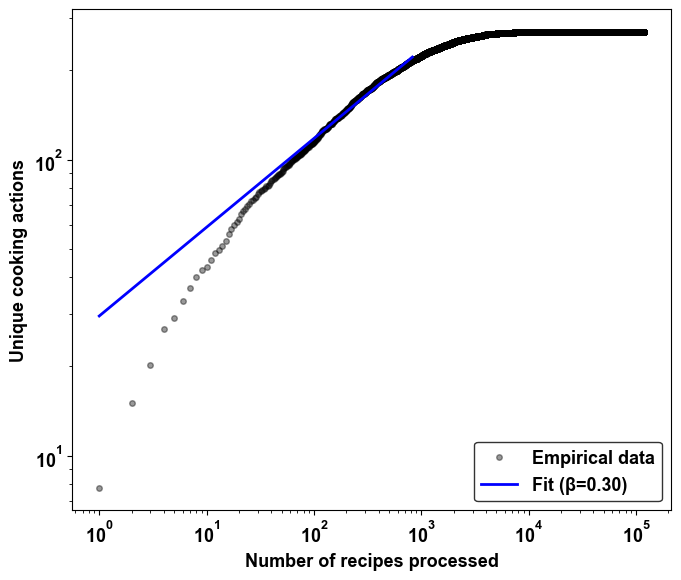

In [20]:


# =============================================================================
# CELL 4 — Heaps' Law rigorous fit + AIC comparison
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True, loc='lower right')
    if legend:
        legend.get_frame().set_edgecolor("black")

print("Loading data...")
df_actions_raw = pd.read_excel("Datasets/RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})

print("\n--- Processing Heaps' law (rigorous fit) ---")
recipe_groups = df_actions.groupby('recipe_no')['action_id'].apply(set).tolist()
n_recipes     = len(recipe_groups)
num_simulations = 10
v_history = np.zeros((num_simulations, n_recipes))
print(f"Running {num_simulations} simulations...")

for i in range(num_simulations):
    shuffled   = np.random.permutation(np.array(recipe_groups, dtype=object))
    unique_set = set()
    current_v  = []
    for r in shuffled:
        unique_set.update(r)
        current_v.append(len(unique_set))
    v_history[i, :] = current_v

y_mean = np.mean(v_history, axis=0)
x_data = np.arange(1, n_recipes + 1)

# FIX: fit only the pre-saturation growth region (up to 80% of V_max)
v_max   = y_mean[-1]
sat_idx = int(np.argmax(y_mean >= 0.80 * v_max))
sat_idx = max(sat_idx, 10)
x_fit   = x_data[:sat_idx]
y_fit   = y_mean[:sat_idx]

def heaps_model(x, K, beta):
    return K * (x ** beta)

def linear_model(x, m, c):
    return m * x + c

popt_heaps, _ = curve_fit(heaps_model, x_fit, y_fit, p0=[10, 0.4])
popt_lin,   _ = curve_fit(linear_model, x_fit, y_fit, p0=[1, 0])

def calculate_aic(y_true, y_pred, num_params):
    rss = np.sum((y_true - y_pred) ** 2)
    n   = len(y_true)
    return n * np.log(rss / n) + 2 * num_params

y_pred_heaps = heaps_model(x_fit, *popt_heaps)
y_pred_lin   = linear_model(x_fit, *popt_lin)
aic_heaps    = calculate_aic(y_fit, y_pred_heaps, 2)
aic_lin      = calculate_aic(y_fit, y_pred_lin,   2)

print("-" * 30)
print(f"Heaps law parameters (fit over first {sat_idx} recipes — pre-saturation):")
print(f"  Constant (K): {popt_heaps[0]:.4f}")
print(f"  Exponent (β): {popt_heaps[1]:.4f}")
print("-" * 30)
print("Model comparison (AIC):")
print(f"  Heaps law:    {aic_heaps:.2f}")
print(f"  Linear model: {aic_lin:.2f}")
print("Result: Evidence favors Heaps law." if aic_heaps < aic_lin else "Result: Evidence favors linear growth.")
print("-" * 30)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(x_data, y_mean, marker='o', linestyle='none', color='black', markersize=4, alpha=0.4, label='Empirical data')
ax.plot(x_fit, y_pred_heaps, color='blue', linestyle='-', linewidth=2, label=f'Fit (β={popt_heaps[1]:.2f})')
ax.set_xlabel("Number of recipes processed", fontweight="bold")
ax.set_ylabel("Unique cooking actions", fontweight="bold")
ax.set_xscale('log')
ax.set_yscale('log')
format_axes(ax)
plt.tight_layout()
plt.savefig("heaps_action_law_rigorous_fit.png", dpi=300)
plt.savefig("heaps_action_law_rigorous_fit.tif", dpi=300)
plt.show()




--- Processing Menzerath-Altmann (Likelihood method) ---
  Full MA model LL: 132.1768
  Power law model LL: 109.3800
  Statistic D: 45.5935  p-value: 0.000000
Result: Evidence favors full Menzerath-Altmann law.


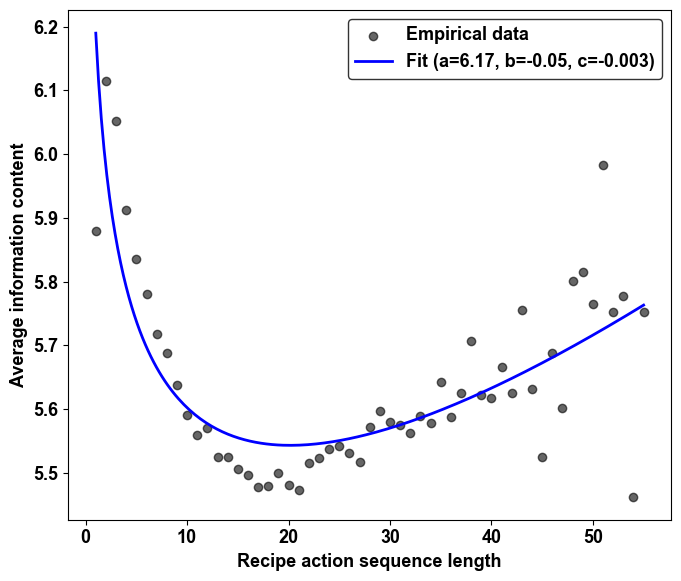

In [21]:

# =============================================================================
# CELL 5 — Menzerath-Altmann likelihood ratio test
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

df_actions_raw = pd.read_excel("Datasets/RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})

print("\n--- Processing Menzerath-Altmann (Likelihood method) ---")
action_counts = df_actions['action_id'].value_counts()
probs = action_counts / len(df_actions)
df_actions['ic'] = -np.log2(df_actions['action_id'].map(probs))
groups = df_actions.groupby('recipe_no')
ma_data = pd.DataFrame({'Length': groups.size(), 'Mean_IC': groups['ic'].mean()})
ma_grouped = ma_data.groupby('Length')['Mean_IC'].mean().reset_index()
valid_counts  = ma_data['Length'].value_counts()
valid_lengths = valid_counts[valid_counts >= 10].index
ma_grouped    = ma_grouped[ma_grouped['Length'].isin(valid_lengths)].sort_values('Length')
x_data    = ma_grouped['Length'].values
y_data    = ma_grouped['Mean_IC'].values
n_samples = len(y_data)

def ma_model(x, A, b, c):
    return A * (x ** b) * np.exp(-c * x)

def power_model(x, A, b):
    return A * (x ** b)

fit_success = False
try:
    popt_ma, _ = curve_fit(ma_model, x_data, y_data, p0=[10, -0.1, 0.01], maxfev=10000)
    y_pred_ma  = ma_model(x_data, *popt_ma)
    rss_ma     = np.sum((y_data - y_pred_ma) ** 2)
    fit_success = True
except:
    pass

try:
    popt_pow, _ = curve_fit(power_model, x_data, y_data, p0=[10, -0.1], maxfev=10000)
    y_pred_pow  = power_model(x_data, *popt_pow)
    rss_pow     = np.sum((y_data - y_pred_pow) ** 2)
except:
    fit_success = False

if fit_success:
    ll_ma  = -0.5 * n_samples * np.log(rss_ma  / n_samples)
    ll_pow = -0.5 * n_samples * np.log(rss_pow / n_samples)
    D      = -2 * (ll_pow - ll_ma)
    p_value = chi2.sf(D, df=1)
    print(f"  Full MA model LL: {ll_ma:.4f}")
    print(f"  Power law model LL: {ll_pow:.4f}")
    print(f"  Statistic D: {D:.4f}  p-value: {p_value:.6f}")
    if p_value < 0.05:
        print("Result: Evidence favors full Menzerath-Altmann law.")
        best_model_label = f'Fit (a={popt_ma[0]:.2f}, b={popt_ma[1]:.2f}, c={popt_ma[2]:.3f})'
        model_func   = ma_model
        model_params = popt_ma
    else:
        print("Result: Evidence favors simple power law.")
        best_model_label = f'Fit (a={popt_pow[0]:.2f}, b={popt_pow[1]:.2f})'
        model_func   = power_model
        model_params = popt_pow

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(x_data, y_data, color='black', alpha=0.6, label='Empirical data')
    x_line = np.linspace(x_data.min(), x_data.max(), 200)
    ax.plot(x_line, model_func(x_line, *model_params), color='blue', linewidth=2, label=best_model_label)
    ax.set_xlabel("Recipe action sequence length", fontweight="bold")
    ax.set_ylabel("Average information content", fontweight="bold")
    format_axes(ax)
    plt.tight_layout()
    plt.savefig("menzerath_altmann_action_likelihood_test.png", dpi=300)
    plt.savefig("menzerath_altmann_action_likelihood_test.tif", dpi=300)
    plt.show()
else:
    print("Optimization failed.")


In [22]:


# =============================================================================
# CELL 6 — Zipf parameters export to CSV
# =============================================================================

import pandas as pd
import numpy as np
import powerlaw

print("Loading data...")
df_actions_raw = pd.read_excel("Datasets/RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})

data  = df_actions['action_id'].value_counts().values
fit   = powerlaw.Fit(data, discrete=True, verbose=False)
alpha = fit.alpha
sigma = fit.sigma
xmin  = fit.xmin
ci_lower = alpha - 1.96 * sigma
ci_upper = alpha + 1.96 * sigma
beta     = 1.0 / (alpha - 1.0)

print("-" * 40)
print(f"RESULTS FOR LIKELIHOOD FIT (xmin={xmin})")
print("-" * 40)
print(f"Alpha:          {alpha:.6f}")
print(f"Sigma:          {sigma:.6f}")
print(f"95% CI:         [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"Beta:           {beta:.6f}")
print("-" * 40)

pd.DataFrame({"xmin":[xmin],"alpha":[alpha],"sigma":[sigma],"ci_lower":[ci_lower],"ci_upper":[ci_upper],"beta":[beta]}).to_csv("zipf_action_law_parameters.csv", index=False)
print("Results exported to zipf_action_law_parameters.csv")



Loading data...
----------------------------------------
RESULTS FOR LIKELIHOOD FIT (xmin=144.0)
----------------------------------------
Alpha:          1.451492
Sigma:          0.031767
95% CI:         [1.389229, 1.513755]
Beta:           2.214878
----------------------------------------
Results exported to zipf_action_law_parameters.csv


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


Power law vs Lognormal:   R=-2.6340, p=0.0084 → Lognormal
Power law vs Exponential: R=5.7843, p=0.0000 → Power law


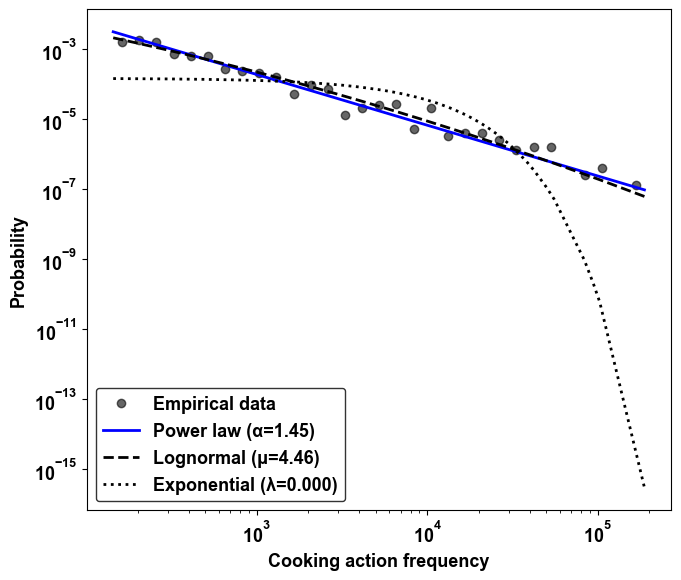

In [23]:

# =============================================================================
# CELL 7 — Distribution model comparison plot
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

df_actions_raw = pd.read_excel("Datasets/RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})

data = df_actions['action_id'].value_counts().values
fit  = powerlaw.Fit(data, discrete=True, verbose=False)
xmin = fit.xmin
alpha     = fit.power_law.alpha
sigma     = fit.power_law.sigma
mu        = fit.lognormal.mu
sigma_log = fit.lognormal.sigma
lamb      = fit.exponential.parameter1

R_pl_ln, p_pl_ln = fit.distribution_compare('power_law', 'lognormal',   normalized_ratio=True)
R_pl_ex, p_pl_ex = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)
winner_ln = "Power law" if R_pl_ln > 0 else "Lognormal"
winner_ex = "Power law" if R_pl_ex > 0 else "Exponential"
print(f"Power law vs Lognormal:   R={R_pl_ln:.4f}, p={p_pl_ln:.4f} → {winner_ln}")
print(f"Power law vs Exponential: R={R_pl_ex:.4f}, p={p_pl_ex:.4f} → {winner_ex}")

pd.DataFrame({
    "xmin":[xmin],"alpha":[alpha],"sigma_alpha":[sigma],
    "lognormal_mu":[mu],"lognormal_sigma":[sigma_log],"exponential_lambda":[lamb],
    "R_powerlaw_lognormal":[R_pl_ln],"p_powerlaw_lognormal":[p_pl_ln],
    "R_powerlaw_exponential":[R_pl_ex],"p_powerlaw_exponential":[p_pl_ex],
    "winner_vs_lognormal":[winner_ln],"winner_vs_exponential":[winner_ex]
}).to_csv("action_distribution_model_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 6))
fit.plot_pdf(color='black', linestyle='none', marker='o', alpha=0.6, markersize=6, label='Empirical data', ax=ax)
fit.power_law.plot_pdf(color='blue',  linestyle='-',  linewidth=2, label=f'Power law (α={alpha:.2f})', ax=ax)
fit.lognormal.plot_pdf(color='black', linestyle='--', linewidth=2, label=f'Lognormal (μ={mu:.2f})',   ax=ax)
fit.exponential.plot_pdf(color='black', linestyle=':', linewidth=2, label=f'Exponential (λ={lamb:.3f})', ax=ax)
ax.set_xlabel("Cooking action frequency", fontweight="bold")
ax.set_ylabel("Probability", fontweight="bold")
ax.set_xscale("log")
ax.set_yscale("log")
format_axes(ax)
plt.tight_layout()
plt.savefig("action_distribution_comparison_models.png", dpi=300)
plt.savefig("action_distribution_comparison_models.tif", dpi=300)
plt.show()


In [24]:


# =============================================================================
# CELL 8 — Zipf α per cuisine (all cuisines, no cutoff)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

df_actions_raw = pd.read_excel("Datasets/RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_excel("Datasets/RecipeID_Cuisine.xlsx").rename(columns={'Region': 'Cuisine'})
df_merged  = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

cuisines = df_merged['Cuisine'].unique()
results  = []
print(f"Analyzing {len(cuisines)} cuisines...")

for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine]
    counts = subset['action_id'].value_counts()
    freqs  = counts.values
    ranks  = np.arange(1, len(freqs) + 1)
    limit_head = 10 if len(freqs) > 50 else 0
    mask = (ranks >= limit_head)
    if np.sum(mask) > 5:
        slope, intercept, r_value, p_value, std_err = linregress(np.log(ranks[mask]), np.log(freqs[mask]))
        alpha       = -slope
        alpha_ci_95 = 1.96 * std_err
        results.append({'Cuisine': cuisine, 'Alpha': alpha,
                        'Alpha_Low': alpha - alpha_ci_95, 'Alpha_High': alpha + alpha_ci_95,
                        'R_Squared': r_value**2})

df_results = pd.DataFrame(results).sort_values('Alpha', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
x_positions = np.arange(len(df_results))
y_errs = [df_results['Alpha'] - df_results['Alpha_Low'], df_results['Alpha_High'] - df_results['Alpha']]
ax.errorbar(x_positions, df_results['Alpha'], yerr=y_errs, fmt='o', capsize=4, color='black', label='Empirical data (95% CI)')
mean_alpha = df_results['Alpha'].mean()
std_alpha  = df_results['Alpha'].std()
ax.axhline(mean_alpha, color='blue', linestyle='-', linewidth=2, label=f'Mean α ({mean_alpha:.2f})')
x_band = np.concatenate(([x_positions[0]-0.5], x_positions, [x_positions[-1]+0.5]))
ax.fill_between(x_band, np.repeat(mean_alpha - std_alpha, len(x_band)), np.repeat(mean_alpha + std_alpha, len(x_band)), color='blue', alpha=0.1, label='Standard deviation')
ax.set_ylabel("Zipf exponent (α)", fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(df_results['Cuisine'], rotation=90)
ax.margins(x=0)
format_axes(ax)
plt.tight_layout()
plt.savefig("zipf_action_alpha_by_cuisine.png", dpi=300)
plt.savefig("zipf_action_alpha_by_cuisine.tif", dpi=300)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'Datasets/RecipeID_Cuisine.xlsx'

Analyzing 26 cuisines...


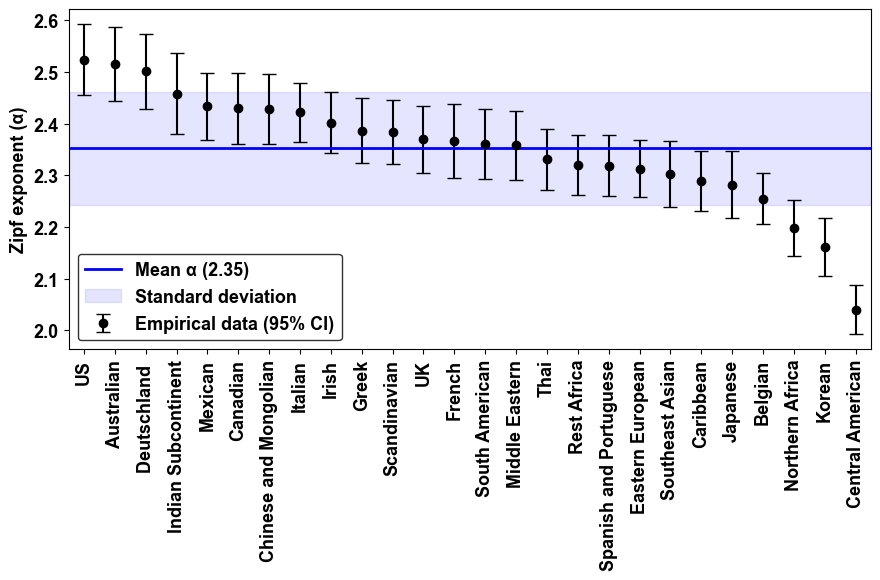

In [ ]:


# =============================================================================
# CELL 9 — Zipf α per cuisine (universality plot)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

df_actions_raw = pd.read_excel("Datasets/RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv").rename(columns={'Region': 'Cuisine'})
df_merged  = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

cuisines = df_merged['Cuisine'].unique()
results  = []
print(f"Analyzing {len(cuisines)} cuisines...")

for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine]
    counts = subset['action_id'].value_counts()
    freqs  = counts.values
    ranks  = np.arange(1, len(freqs) + 1)
    limit_head = 10 if len(freqs) > 50 else 0
    mask = (ranks >= limit_head)
    if np.sum(mask) > 5:
        slope, intercept, r_value, p_value, std_err = linregress(np.log(ranks[mask]), np.log(freqs[mask]))
        alpha       = -slope
        alpha_ci_95 = 1.96 * std_err
        results.append({'Cuisine': cuisine, 'Alpha': alpha,
                        'Alpha_Low': alpha - alpha_ci_95, 'Alpha_High': alpha + alpha_ci_95,
                        'R_Squared': r_value**2})

df_results = pd.DataFrame(results).sort_values('Alpha', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
x_positions = np.arange(len(df_results))
y_errs = [df_results['Alpha'] - df_results['Alpha_Low'], df_results['Alpha_High'] - df_results['Alpha']]
ax.errorbar(x_positions, df_results['Alpha'], yerr=y_errs, fmt='o', capsize=5, color='black', label='Empirical data (95% CI)')
mean_alpha = df_results['Alpha'].mean()
std_alpha  = df_results['Alpha'].std()
ax.axhline(mean_alpha, color='blue', linestyle='-', linewidth=2, label=f'Mean α ({mean_alpha:.2f})')
x_band = np.concatenate(([x_positions[0]-0.5], x_positions, [x_positions[-1]+0.5]))
ax.fill_between(x_band, np.repeat(mean_alpha - std_alpha, len(x_band)), np.repeat(mean_alpha + std_alpha, len(x_band)), color='blue', alpha=0.1, label='Standard deviation')
ax.set_ylabel("Zipf exponent (α)", fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(df_results['Cuisine'], rotation=90)
ax.margins(x=0)
format_axes(ax)
plt.tight_layout()
plt.savefig("cuisine_action_zipf_alpha_universality.png", dpi=300)
plt.savefig("cuisine_action_zipf_alpha_universality.tif", dpi=300)
plt.show()



In [ ]:

# =============================================================================
# CELL 10 — Zipf α per cuisine → CSV export
# =============================================================================

import pandas as pd
import numpy as np
from scipy.stats import linregress

print("Loading data...")
df_actions_raw = pd.read_excel("Datasets/RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv").rename(columns={'Region': 'Cuisine'})
df_merged  = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

cuisines = df_merged['Cuisine'].unique()
results  = []
print(f"Calculating Zipf α for {len(cuisines)} cuisines...")

for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine]
    counts = subset['action_id'].value_counts()
    freqs  = counts.values
    ranks  = np.arange(1, len(freqs) + 1)
    limit_head = 10 if len(freqs) > 50 else 0
    mask = (ranks >= limit_head)
    if np.sum(mask) > 5:
        slope, intercept, r_value, p_value, std_err = linregress(np.log(ranks[mask]), np.log(freqs[mask]))
        alpha       = -slope
        alpha_ci_95 = 1.96 * std_err
        results.append({'Cuisine': cuisine,
                        'Alpha': round(alpha, 4),
                        'Lower_CI_95': round(alpha - alpha_ci_95, 4),
                        'Upper_CI_95': round(alpha + alpha_ci_95, 4),
                        'R_Squared': round(r_value**2, 4)})

df_results = pd.DataFrame(results).sort_values('Alpha', ascending=False)
print("\n=== Zipf's Law α by Cuisine (Cooking Actions) ===")
print(df_results.to_string(index=False))
df_results.to_csv("zipf_alphas_actions_by_cuisine.csv", index=False)
print("\nResults exported to: zipf_alphas_actions_by_cuisine.csv")



Loading data...
Calculating Zipf α for 26 cuisines...

=== Zipf's Law α by Cuisine (Cooking Actions) ===
               Cuisine  Alpha  Lower_CI_95  Upper_CI_95  R_Squared
                    US 2.5240       2.4560       2.5920     0.9575
            Australian 2.5158       2.4437       2.5879     0.9492
          Deutschland  2.5011       2.4286       2.5735     0.9488
   Indian Subcontinent 2.4581       2.3795       2.5368     0.9382
               Mexican 2.4332       2.3679       2.4985     0.9542
              Canadian 2.4296       2.3608       2.4983     0.9503
 Chinese and Mongolian 2.4285       2.3602       2.4968     0.9514
               Italian 2.4216       2.3653       2.4780     0.9652
                 Irish 2.4022       2.3440       2.4603     0.9652
                 Greek 2.3865       2.3234       2.4496     0.9565
          Scandinavian 2.3837       2.3218       2.4457     0.9600
                    UK 2.3696       2.3041       2.4350     0.9523
                French 2

In [ ]:

# =============================================================================
# CELL 11 — Heaps β per cuisine (plot)
# =============================================================================
# FIX: fit only pre-saturation growth region (up to 80% of V_max per cuisine)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

df_actions_raw = pd.read_excel("RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_excel("RecipeID_Cuisine.xlsx").rename(columns={'Region': 'Cuisine'})
df_merged  = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

cuisines = df_merged['Cuisine'].unique()
results  = []
print(f"Calculating Heaps β for {len(cuisines)} cuisines (pre-saturation fit)...")

for cuisine in cuisines:
    subset  = df_merged[df_merged['Cuisine'] == cuisine]
    recipes = subset.groupby('recipe_no')['action_id'].apply(set).tolist()
    np.random.seed(42)
    shuffled = np.random.permutation(np.array(recipes, dtype=object))
    unique_actions, x_n, y_v, total = set(), [], [], 0
    sample_rate = 10 if len(shuffled) < 1000 else 50
    for i, r in enumerate(shuffled):
        unique_actions.update(r)
        total += len(r)
        if (i + 1) % sample_rate == 0:
            x_n.append(total)
            y_v.append(len(unique_actions))
    if len(x_n) > 5:
        # Fit only the pre-saturation region (up to 80% of V_max)
        v_max   = max(y_v)
        sat_idx = next((i for i, v in enumerate(y_v) if v >= 0.80 * v_max), len(y_v))
        sat_idx = max(sat_idx, 6)   # need at least 6 points
        x_fit   = np.array(x_n[:sat_idx])
        y_fit   = np.array(y_v[:sat_idx])
        slope, intercept, _, _, std_err = linregress(np.log(x_fit), np.log(y_fit))
        results.append({'Cuisine':  cuisine,
                        'Beta':     slope,
                        'Beta_Low': slope - 1.96 * std_err,
                        'Beta_High':slope + 1.96 * std_err})

df_results = pd.DataFrame(results).sort_values('Beta', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
x_positions = np.arange(len(df_results))
y_errs = [df_results['Beta'] - df_results['Beta_Low'], df_results['Beta_High'] - df_results['Beta']]
ax.errorbar(x_positions, df_results['Beta'], yerr=y_errs, fmt='o', capsize=5, color='black', label='Empirical data (95% CI)')
mean_beta = df_results['Beta'].mean()
std_beta  = df_results['Beta'].std()
ax.axhline(mean_beta, color='blue', linestyle='-', linewidth=2, label=f'Mean β ({mean_beta:.2f})')
x_band = np.concatenate(([x_positions[0]-0.5], x_positions, [x_positions[-1]+0.5]))
ax.fill_between(x_band, np.repeat(mean_beta - std_beta, len(x_band)), np.repeat(mean_beta + std_beta, len(x_band)), color='blue', alpha=0.1, label='Standard deviation')
ax.set_ylabel("Heaps exponent (β)", fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(df_results['Cuisine'], rotation=90)
ax.margins(x=0)
ax.grid(False)
legend = ax.legend(frameon=True)
if legend:
    legend.get_frame().set_edgecolor("black")
plt.tight_layout()
plt.savefig("heaps_action_beta_by_cuisine.png", dpi=300)
plt.savefig("heaps_action_beta_by_cuisine.tif", dpi=300)
plt.show()



In [ ]:

# =============================================================================
# CELL 12 — Heaps β per cuisine → CSV export
# =============================================================================
# FIX: same pre-saturation fit as Cell 11

import pandas as pd
import numpy as np
from scipy.stats import linregress

print("Loading data...")
df_actions_raw = pd.read_excel("RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_excel("RecipeID_Cuisine.xlsx").rename(columns={'Region': 'Cuisine'})
df_merged  = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

cuisines = df_merged['Cuisine'].unique()
results  = []
print(f"Calculating Heaps β for {len(cuisines)} cuisines (pre-saturation fit)...")

for cuisine in cuisines:
    subset  = df_merged[df_merged['Cuisine'] == cuisine]
    recipes = subset.groupby('recipe_no')['action_id'].apply(set).tolist()
    np.random.seed(42)
    shuffled = np.random.permutation(np.array(recipes, dtype=object))
    unique_actions, x_n, y_v, total = set(), [], [], 0
    sample_rate = 10 if len(shuffled) < 1000 else 50
    for i, r in enumerate(shuffled):
        unique_actions.update(r)
        total += len(r)
        if (i + 1) % sample_rate == 0 or (i + 1) == len(shuffled):
            x_n.append(total)
            y_v.append(len(unique_actions))
    if len(x_n) > 5:
        v_max   = max(y_v)
        sat_idx = next((i for i, v in enumerate(y_v) if v >= 0.80 * v_max), len(y_v))
        sat_idx = max(sat_idx, 6)
        x_fit   = np.array(x_n[:sat_idx])
        y_fit   = np.array(y_v[:sat_idx])
        slope, intercept, r_value, p_value, std_err = linregress(np.log(x_fit), np.log(y_fit))
        beta        = slope
        beta_ci_95  = 1.96 * std_err
        results.append({'Cuisine':     cuisine,
                        'Beta':        round(beta, 4),
                        'Lower_CI_95': round(beta - beta_ci_95, 4),
                        'Upper_CI_95': round(beta + beta_ci_95, 4),
                        'R_Squared':   round(r_value**2, 4),
                        'Num_Recipes': len(recipes)})

df_results = pd.DataFrame(results).sort_values('Beta', ascending=False)
print("\n=== Heaps' Law β by Cuisine (Cooking Actions — pre-saturation fit) ===")
print(df_results.to_string(index=False))
df_results.to_csv("heaps_betas_actions_by_cuisine.csv", index=False)
print("\nResults exported to: heaps_betas_actions_by_cuisine.csv")



In [ ]:

# =============================================================================
# CELL 13 — MA per cuisine (two plots: legend + labels)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

df_actions_raw = pd.read_excel("RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_excel("RecipeID_Cuisine.xlsx").rename(columns={'Region': 'Cuisine'})
df_merged  = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

cuisines   = df_merged['Cuisine'].unique()
results_ma = []

def ma_model(x, A, b, c):
    return A * (x**b) * np.exp(-c*x)

fig, ax = plt.subplots(figsize=(9, 6))
for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine].copy()
    probs  = subset['action_id'].value_counts() / len(subset)
    subset['ic'] = -np.log2(subset['action_id'].map(probs))
    recipe_stats = subset.groupby('recipe_no').agg(length=('action_id', 'count'), mean_ic=('ic', 'mean'))
    ma_data = recipe_stats.groupby('length')['mean_ic'].mean().reset_index()
    counts  = recipe_stats['length'].value_counts()
    ma_data = ma_data[ma_data['length'].isin(counts[counts >= 5].index)].sort_values('length')
    if len(ma_data) > 5:
        x_data, y_data = ma_data['length'].values, ma_data['mean_ic'].values
        try:
            popt, _ = curve_fit(ma_model, x_data, y_data, p0=[np.mean(y_data), -0.1, -0.01], maxfev=10000)
            results_ma.append({'Cuisine': cuisine, 'a': popt[0], 'b': popt[1], 'c': popt[2]})
            x_line = np.linspace(min(x_data), max(x_data), 200)
            ax.plot(x_line, ma_model(x_line, *popt), alpha=0.7, label=cuisine)
        except:
            pass

ax.set_xlabel("Recipe action sequence length", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")
ax.grid(False)
legend = ax.legend(frameon=True, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
if legend:
    legend.get_frame().set_edgecolor("black")
plt.tight_layout()
plt.savefig("menzerath_altmann_actions_cuisines.png", dpi=300)
plt.savefig("menzerath_altmann_actions_cuisines.tif", dpi=300)
plt.show()

df_params = pd.DataFrame(results_ma)
print("\n=== Menzerath-Altmann Parameters by Cuisine (Cooking Actions) ===")
print(df_params.to_string(index=False))
df_params.to_csv("menzerath_altmann_actions_parameters_by_cuisine.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 6))
for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine].copy()
    probs  = subset['action_id'].value_counts() / len(subset)
    subset['ic'] = -np.log2(subset['action_id'].map(probs))
    recipe_stats = subset.groupby('recipe_no').agg(length=('action_id', 'count'), mean_ic=('ic', 'mean'))
    ma_data = recipe_stats.groupby('length')['mean_ic'].mean().reset_index()
    counts  = recipe_stats['length'].value_counts()
    ma_data = ma_data[ma_data['length'].isin(counts[counts >= 5].index)].sort_values('length')
    if len(ma_data) > 5:
        x_data, y_data = ma_data['length'].values, ma_data['mean_ic'].values
        try:
            popt, _ = curve_fit(ma_model, x_data, y_data, p0=[np.mean(y_data), -0.1, -0.01], maxfev=10000)
            x_line = np.linspace(min(x_data), max(x_data), 200)
            y_line = ma_model(x_line, *popt)
            ax.plot(x_line, y_line, alpha=0.7)
            ax.text(x_line[-1], y_line[-1], cuisine, fontsize=8, fontweight='normal', va='center')
        except:
            pass

ax.set_xlabel("Recipe action sequence length", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")
ax.grid(False)
plt.tight_layout()
plt.savefig("menzerath_altmann_actions_cuisines_labeled.png", dpi=300)
plt.savefig("menzerath_altmann_actions_cuisines_labeled.tif", dpi=300)
plt.show()



In [ ]:

# =============================================================================
# CELL 14 — Zipf α per cuisine (refined, no cutoff)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

plt.rcParams.update({
    "font.family": "Arial", "font.size": 13, "font.weight": "bold",
    "axes.labelweight": "bold", "axes.linewidth": 1.2,
    "legend.frameon": True, "legend.edgecolor": "black", "legend.framealpha": 1.0,
})

df_actions_raw = pd.read_excel("RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_excel("RecipeID_Cuisine.xlsx").rename(columns={'Region': 'Cuisine'})
df_merged  = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

cuisines = df_merged["Cuisine"].dropna().unique()
results  = []
print(f"Analyzing {len(cuisines)} cuisines...")

for cuisine in cuisines:
    subset = df_merged[df_merged["Cuisine"] == cuisine]
    counts = subset["action_id"].value_counts()
    freqs  = counts.values
    ranks  = np.arange(1, len(freqs) + 1)
    limit_head = 10 if len(freqs) > 50 else 0
    mask = ranks >= limit_head
    if np.sum(mask) > 5:
        slope, intercept, r_value, p_value, std_err = linregress(np.log(ranks[mask]), np.log(freqs[mask]))
        alpha       = -slope
        alpha_ci_95 = 1.96 * std_err
        results.append({"Cuisine": cuisine, "Alpha": alpha,
                        "Alpha_Low": alpha - alpha_ci_95, "Alpha_High": alpha + alpha_ci_95,
                        "R_Squared": r_value**2})

df_results = pd.DataFrame(results).sort_values("Alpha", ascending=False).reset_index(drop=True)
if df_results.empty:
    raise RuntimeError("No cuisines had enough data points.")

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(df_results))
y = df_results["Alpha"].to_numpy()
ax.errorbar(x, y,
            yerr=[(df_results["Alpha"] - df_results["Alpha_Low"]).to_numpy(),
                  (df_results["Alpha_High"] - df_results["Alpha"]).to_numpy()],
            fmt="o", markersize=5, capsize=5, color="black", ecolor="black", elinewidth=1.2,
            label="Empirical data (95% CI)")
mean_alpha = float(df_results["Alpha"].mean())
std_alpha  = float(df_results["Alpha"].std())
ax.axhline(mean_alpha, color="blue", linestyle="-", linewidth=2, label=f"Mean α ({mean_alpha:.2f})")
x_band = np.linspace(-0.5, len(x)-0.5, 400)
ax.fill_between(x_band, np.full_like(x_band, mean_alpha - std_alpha), np.full_like(x_band, mean_alpha + std_alpha), color="blue", alpha=0.1, label="Standard deviation")
ax.set_xlim(-0.5, len(x)-0.5)
ax.set_ylabel("Zipf exponent (α)")
ax.set_xticks(x)
ax.set_xticklabels(df_results["Cuisine"], rotation=90)
for spine in ax.spines.values():
    spine.set_visible(True); spine.set_linewidth(1.2)
ax.grid(False)
ax.legend(loc="upper right")
fig.tight_layout()
fig.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.30)
fig.savefig("zipf_action_alpha_by_cuisine_all.png", dpi=300, bbox_inches="tight")
fig.savefig("zipf_action_alpha_by_cuisine_all.tif", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:

# =============================================================================
# CELL 15 — Zip outputs
# =============================================================================

import zipfile, os
zip_filename = "results_plots_actions.zip"
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in os.listdir():
        if file.endswith((".png", ".tif", ".csv")):
            zipf.write(file)
print("ZIP created:", zip_filename)


In [ ]:


# =============================================================================
# CELL 16 — CUTOFF (markdown marker)
# =============================================================================


In [ ]:


# =============================================================================
# CELL 17 — Zipf α per cuisine WITH cutoff + filtered plot
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

plt.rcParams.update({
    "font.family": "Arial", "font.size": 13, "font.weight": "bold",
    "axes.labelweight": "bold", "axes.linewidth": 1.2,
    "legend.frameon": True, "legend.edgecolor": "black", "legend.framealpha": 1.0,
})

df_actions_raw = pd.read_excel("RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_excel("RecipeID_Cuisine.xlsx").rename(columns={'Region': 'Cuisine'})
df_merged  = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

recipe_counts = df_merged.groupby('Cuisine')['recipe_no'].nunique()
target_drops  = ["Central American", "Korean", "Belgian"]
drop_counts   = recipe_counts[recipe_counts.index.isin(target_drops)]
MIN_RECIPES   = int(drop_counts.max()) + 1 if not drop_counts.empty else 50
print(f"Automatically set MIN_RECIPES cutoff to: {MIN_RECIPES}")
valid_cuisines = recipe_counts[recipe_counts >= MIN_RECIPES].index
df_merged      = df_merged[df_merged['Cuisine'].isin(valid_cuisines)]
print(f"Remaining cuisines after cutoff: {len(valid_cuisines)}")

cuisines = df_merged["Cuisine"].dropna().unique()
results  = []
print(f"Analyzing {len(cuisines)} cuisines...")

for cuisine in cuisines:
    subset = df_merged[df_merged["Cuisine"] == cuisine]
    counts = subset["action_id"].value_counts()
    freqs  = counts.values
    ranks  = np.arange(1, len(freqs) + 1)
    limit_head = 10 if len(freqs) > 50 else 0
    mask = ranks >= limit_head
    if np.sum(mask) > 5:
        slope, intercept, r_value, p_value, std_err = linregress(np.log(ranks[mask]), np.log(freqs[mask]))
        alpha       = -slope
        alpha_ci_95 = 1.96 * std_err
        results.append({"Cuisine": cuisine, "Alpha": alpha,
                        "Alpha_Low": alpha - alpha_ci_95, "Alpha_High": alpha + alpha_ci_95,
                        "R_Squared": r_value**2, "Recipe_Count": recipe_counts[cuisine]})

df_results = pd.DataFrame(results).sort_values("Alpha", ascending=False).reset_index(drop=True)
if df_results.empty:
    raise RuntimeError("No cuisines had enough data points.")

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(df_results))
y = df_results["Alpha"].to_numpy()
ax.errorbar(x, y,
            yerr=[(df_results["Alpha"] - df_results["Alpha_Low"]).to_numpy(),
                  (df_results["Alpha_High"] - df_results["Alpha"]).to_numpy()],
            fmt="o", markersize=5, capsize=5, color="black", ecolor="black", elinewidth=1.2,
            label="Empirical data (95% CI)")
mean_alpha = float(df_results["Alpha"].mean())
std_alpha  = float(df_results["Alpha"].std())
ax.axhline(mean_alpha, color="blue", linestyle="-", linewidth=2, label=f"Mean α ({mean_alpha:.2f})")
x_band = np.linspace(-0.5, len(x)-0.5, 400)
ax.fill_between(x_band, np.full_like(x_band, mean_alpha - std_alpha), np.full_like(x_band, mean_alpha + std_alpha), color="blue", alpha=0.1, label="Standard deviation")
ax.set_xlim(-0.5, len(x)-0.5)
ax.set_ylabel("Zipf exponent (α)")
ax.set_xticks(x)
ax.set_xticklabels([f"{row['Cuisine']} (n={row['Recipe_Count']})" for _, row in df_results.iterrows()], rotation=90)
for spine in ax.spines.values():
    spine.set_visible(True); spine.set_linewidth(1.2)
ax.grid(False)
ax.legend(loc="upper right")
fig.tight_layout()
fig.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.30)
fig.savefig("zipf_action_alpha_by_cuisine_filtered.png", dpi=300, bbox_inches="tight")
fig.savefig("zipf_action_alpha_by_cuisine_filtered.tif", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:


# =============================================================================
# CELL 18 — Heaps β per cuisine WITH cutoff
# =============================================================================
# FIX: pre-saturation fit (80% threshold), stats computed BEFORE cutoff applied

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

df_actions_raw = pd.read_excel("RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_excel("RecipeID_Cuisine.xlsx").rename(columns={'Region': 'Cuisine'})
df_merged  = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

recipe_counts = df_merged.groupby('Cuisine')['recipe_no'].nunique()
target_drops  = ["Central American", "Korean", "Belgian"]
drop_counts   = recipe_counts[recipe_counts.index.isin(target_drops)]
MIN_RECIPES   = int(drop_counts.max()) + 1 if not drop_counts.empty else 50
print(f"Automatically set MIN_RECIPES cutoff to: {MIN_RECIPES}")

cuisines = df_merged['Cuisine'].unique()
results  = []
print(f"Calculating Heaps β for {len(cuisines)} cuisines (pre-saturation fit)...")

for cuisine in cuisines:
    subset  = df_merged[df_merged['Cuisine'] == cuisine]
    recipes = subset.groupby('recipe_no')['action_id'].apply(set).tolist()
    np.random.seed(42)
    shuffled = np.random.permutation(np.array(recipes, dtype=object))
    unique_actions, x_n, y_v, total = set(), [], [], 0
    sample_rate = 10 if len(shuffled) < 1000 else 50
    for i, r in enumerate(shuffled):
        unique_actions.update(r)
        total += len(r)
        if (i + 1) % sample_rate == 0:
            x_n.append(total)
            y_v.append(len(unique_actions))
    if len(x_n) > 5:
        v_max   = max(y_v)
        sat_idx = next((i for i, v in enumerate(y_v) if v >= 0.80 * v_max), len(y_v))
        sat_idx = max(sat_idx, 6)
        x_fit   = np.array(x_n[:sat_idx])
        y_fit   = np.array(y_v[:sat_idx])
        slope, intercept, _, _, std_err = linregress(np.log(x_fit), np.log(y_fit))
        results.append({'Cuisine': cuisine, 'Beta': slope,
                        'Beta_Low': slope - 1.96 * std_err, 'Beta_High': slope + 1.96 * std_err,
                        'Recipe_Count': recipe_counts[cuisine]})

df_results = pd.DataFrame(results).sort_values('Beta', ascending=False)

# Stats BEFORE cutoff
original_mean_beta = df_results['Beta'].mean()
original_std_beta  = df_results['Beta'].std()

# Apply cutoff
df_results = df_results[df_results['Recipe_Count'] >= MIN_RECIPES]
print(f"Remaining cuisines after cutoff: {len(df_results)}")

fig, ax = plt.subplots(figsize=(9, 6))
x_positions = np.arange(len(df_results))
y_errs = [df_results['Beta'] - df_results['Beta_Low'], df_results['Beta_High'] - df_results['Beta']]
ax.errorbar(x_positions, df_results['Beta'], yerr=y_errs, fmt='o', capsize=5, color='black', label='Empirical data (95% CI)')
ax.axhline(original_mean_beta, color='blue', linestyle='-', linewidth=2, label=f'Mean β ({original_mean_beta:.2f})')
x_band = np.concatenate(([x_positions[0]-0.5], x_positions, [x_positions[-1]+0.5]))
ax.fill_between(x_band,
                np.repeat(original_mean_beta - original_std_beta, len(x_band)),
                np.repeat(original_mean_beta + original_std_beta, len(x_band)),
                color='blue', alpha=0.1, label='Standard deviation')
ax.set_ylabel("Heaps exponent (β)", fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels([f"{row['Cuisine']} (n={row['Recipe_Count']})" for _, row in df_results.iterrows()], rotation=90)
ax.margins(x=0)
ax.grid(False)
legend = ax.legend(frameon=True)
if legend:
    legend.get_frame().set_edgecolor("black")
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.savefig("heaps_action_beta_by_cuisine_cutoff.png", dpi=300)
plt.savefig("heaps_action_beta_by_cuisine_cutoff.tif", dpi=300)
plt.show()



In [ ]:

# =============================================================================
# CELL 19 — MA per cuisine WITH cutoff
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

df_actions_raw = pd.read_excel("RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_excel("RecipeID_Cuisine.xlsx").rename(columns={'Region': 'Cuisine'})
df_merged  = pd.merge(df_actions, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

recipe_counts = df_merged.groupby('Cuisine')['recipe_no'].nunique()
target_drops  = ["Central American", "Korean", "Belgian"]
drop_counts   = recipe_counts[recipe_counts.index.isin(target_drops)]
MIN_RECIPES   = int(drop_counts.max()) + 1 if not drop_counts.empty else 50
print(f"Automatically set MIN_RECIPES cutoff to: {MIN_RECIPES}")
valid_cuisines = recipe_counts[recipe_counts >= MIN_RECIPES].index
df_merged      = df_merged[df_merged['Cuisine'].isin(valid_cuisines)]
cuisines       = df_merged['Cuisine'].unique()
print(f"Plotting Menzerath-Altmann curves for {len(cuisines)} filtered cuisines...")

def ma_model(x, A, b, c):
    return A * (x**b) * np.exp(-c*x)

results_ma = []
fig, ax    = plt.subplots(figsize=(9, 6))

for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine].copy()
    probs  = subset['action_id'].value_counts() / len(subset)
    subset['ic'] = -np.log2(subset['action_id'].map(probs))
    recipe_stats = subset.groupby('recipe_no').agg(length=('action_id', 'count'), mean_ic=('ic', 'mean'))
    ma_data = recipe_stats.groupby('length')['mean_ic'].mean().reset_index()
    counts  = recipe_stats['length'].value_counts()
    ma_data = ma_data[ma_data['length'].isin(counts[counts >= 5].index)].sort_values('length')
    if len(ma_data) > 5:
        x_data, y_data = ma_data['length'].values, ma_data['mean_ic'].values
        try:
            popt, _ = curve_fit(ma_model, x_data, y_data, p0=[np.mean(y_data), -0.1, -0.01], maxfev=10000)
            results_ma.append({'Cuisine': cuisine, 'a': popt[0], 'b': popt[1], 'c': popt[2], 'Recipe_Count': recipe_counts[cuisine]})
            x_line = np.linspace(min(x_data), max(x_data), 200)
            ax.plot(x_line, ma_model(x_line, *popt), alpha=0.7, label=f"{cuisine} (n={recipe_counts[cuisine]})")
        except:
            pass

ax.set_xlabel("Recipe action sequence length", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")
ax.grid(False)
legend = ax.legend(frameon=True, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
if legend:
    legend.get_frame().set_edgecolor("black")
plt.tight_layout()
plt.savefig("menzerath_altmann_actions_cuisines_cutoff.png", dpi=300)
plt.savefig("menzerath_altmann_actions_cuisines_cutoff.tif", dpi=300)
plt.show()

df_params = pd.DataFrame(results_ma)
print("\n=== Menzerath-Altmann Parameters by Cuisine (Cooking Actions, Filtered) ===")
print(df_params[['Cuisine', 'a', 'b', 'c']].to_string(index=False))
df_params.to_csv("menzerath_altmann_actions_parameters_by_cuisine_cutoff.csv", index=False)



In [ ]:

# =============================================================================
# CELL 20 — Model 1: Fitness-driven Zipf simulation
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

print("Running Fitness-Driven Model for Cooking Actions...")

V_MASTER     = 270
TARGET_ALPHA = 1.50

ranks_master = np.arange(1, V_MASTER + 1)
fitness      = ranks_master ** (-TARGET_ALPHA)
probs        = fitness / np.sum(fitness)

N_TOKENS    = 500000
drawn_items = np.random.choice(V_MASTER, size=N_TOKENS, p=probs)

unique, counts = np.unique(drawn_items, return_counts=True)
frequencies    = np.sort(counts)[::-1]
ranks          = np.arange(1, len(frequencies) + 1)

fit_mask  = (ranks >= 2) & (ranks <= len(ranks))
slope, intercept, r_val, _, _ = linregress(np.log(ranks[fit_mask]), np.log(frequencies[fit_mask]))
zipf_alpha = -slope
print(f"Achieved Zipf α: {zipf_alpha:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ranks, frequencies, marker='o', linestyle='none', color='black', markersize=5, alpha=0.4, label="Simulated Data")
ax.loglog(ranks, np.exp(intercept) * (ranks ** -zipf_alpha), color='blue', linestyle='-', linewidth=2.5, label=f"Fit (α={zipf_alpha:.2f})")
ax.set_xlabel("Rank", fontweight="bold")
ax.set_ylabel("Frequency", fontweight="bold")
format_axes(ax)
plt.tight_layout()
plt.savefig("model1_action_fitness_generation.png", dpi=300)
plt.savefig("model1_action_fitness_generation.tif", dpi=300)
plt.show()



In [ ]:

# =============================================================================
# CELL 21 — Model 2: Heaps' Law simulation
# =============================================================================
# FIX: fit only the pre-saturation growth region of the simulated curve

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

print("Running Zipfian Sampling Model for Heaps' Law (Cooking Actions)...")

V_MASTER     = 270
MASTER_ALPHA = 1.85

ranks_master = np.arange(1, V_MASTER + 1)
fitness      = ranks_master ** (-MASTER_ALPHA)
probs        = fitness / np.sum(fitness)

N_TOTAL_TOKENS = 200000
drawn_items    = np.random.choice(V_MASTER, size=N_TOTAL_TOKENS, p=probs)

_, first_occurrences = np.unique(drawn_items, return_index=True)
first_occurrences.sort()

n_array   = np.arange(50, N_TOTAL_TOKENS, 50)
v_history = np.searchsorted(first_occurrences, n_array)

# FIX: fit only pre-saturation growth region (up to 80% of V_max)
v_max   = v_history[-1]
sat_idx = int(np.argmax(v_history >= 0.80 * v_max))
sat_idx = max(sat_idx, 10)

x_fit_sim = n_array[:sat_idx]
y_fit_sim = v_history[:sat_idx]

slope, intercept, r_val, _, _ = linregress(np.log(x_fit_sim), np.log(y_fit_sim))
heaps_beta = slope
print(f"Achieved Heaps β: {heaps_beta:.4f}  (fitted over first {sat_idx} samples — pre-saturation)")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(n_array, v_history, marker='o', linestyle='none', color='black', markersize=3, alpha=0.3, label="Simulated Data")
ax.plot(x_fit_sim, np.exp(intercept) * (x_fit_sim ** heaps_beta), color='blue', linestyle='-', linewidth=2.5, label=f"Fit (β={heaps_beta:.2f})")
ax.set_xlabel("Total Actions Processed (N)", fontweight="bold")
ax.set_ylabel("Unique Action Vocabulary (V)", fontweight="bold")
ax.set_xscale('log')
ax.set_yscale('log')
format_axes(ax)
plt.tight_layout()
plt.savefig("model2_action_heaps_law_simulated.png", dpi=300)
plt.savefig("model2_action_heaps_law_simulated.tif", dpi=300)
plt.show()



In [ ]:

# =============================================================================
# CELL 22 — Full MA analysis: global + grid + branching
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax, **legend_kwargs):
    ax.grid(False)
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        legend = ax.legend(frameon=True, **legend_kwargs)
        if legend:
            legend.get_frame().set_edgecolor("black")

COLORS = [
    "#3266ad","#D85A30","#1D9E75","#7F77DD","#BA7517","#993556",
    "#0F6E56","#D4537E","#185FA5","#639922","#E24B4A","#5F5E5A",
    "#534AB7","#085041","#993C1D","#3C3489","#0C447C","#3B6D11",
    "#854F0B","#A32D2D","#4B1528","#26215C","#412402","#04342C",
    "#501313","#72243E",
]

MIN_RECIPES = 20
MIN_LENGTHS = 5

print("Loading data...")
df_actions_raw = pd.read_excel("RecipeID_CookingAction_List.xlsx")
df_actions_raw = df_actions_raw.dropna(subset=['Processes'])
df_actions_raw['Processes'] = df_actions_raw['Processes'].astype(str).str.split(r'\|\|')
df_actions = df_actions_raw.explode('Processes').reset_index(drop=True)
df_actions['Processes'] = df_actions['Processes'].str.strip()
df_actions = df_actions.rename(columns={'Recipe_id': 'recipe_no', 'Processes': 'action_id'})
df_cuisine = pd.read_excel("RecipeID_Cuisine.xlsx").rename(columns={'Region': 'Cuisine'})

recipe_actions = df_actions.groupby('recipe_no')['action_id'].apply(list).to_dict()
all_actions    = df_actions['action_id'].values
counts_global  = Counter(all_actions)
total_global   = sum(counts_global.values())
ic_lookup      = {a: -np.log2(c / total_global) for a, c in counts_global.items()}
cuisine_map    = df_cuisine.groupby('Cuisine')['Recipe_id'].apply(list).to_dict()
print(f"  Unique actions:  {len(ic_lookup)}")
print(f"  Unique cuisines: {len(cuisine_map)}")

def empirical_ic_by_length(recipe_ids, min_recipes=MIN_RECIPES):
    buckets = {}
    for rid in recipe_ids:
        r = recipe_actions.get(rid, [])
        if not r:
            continue
        L   = len(r)
        ics = [ic_lookup[a] for a in r if a in ic_lookup]
        if ics:
            buckets.setdefault(L, []).append(np.mean(ics))
    lengths, mean_ics = [], []
    for L, vals in sorted(buckets.items()):
        if len(vals) >= min_recipes:
            lengths.append(L)
            mean_ics.append(np.mean(vals))
    return np.array(lengths), np.array(mean_ics)

def ma_curve(x, a, b, c):
    return a * (x ** b) * np.exp(-c * x)

def fit_ma(lengths, ics, p0=(10.0, -0.25, -0.018)):
    try:
        popt, _ = curve_fit(ma_curve, lengths, ics, p0=p0, maxfev=20000,
                            bounds=([-np.inf,-np.inf,-np.inf],[np.inf,0,0]))
        residuals = ics - ma_curve(lengths, *popt)
        ss_res = (residuals**2).sum()
        ss_tot = ((ics - ics.mean())**2).sum()
        r2     = 1.0 - ss_res/ss_tot if ss_tot > 0 else 0.0
        return popt.tolist(), round(r2, 4)
    except:
        return None, None

def min_ic_length(a, b, c, x_range=(1, 60)):
    xs = np.linspace(x_range[0], x_range[1], 1000)
    return round(float(xs[np.argmin(ma_curve(xs, a, b, c))]), 1)

def smooth_fit(a, b, c, lengths, n=300):
    xs = np.linspace(lengths.min(), lengths.max(), n)
    return xs, ma_curve(xs, a, b, c)

print("\nFitting MA curves per cuisine...")
results = {}
for cuisine, rids in sorted(cuisine_map.items()):
    lengths, ics = empirical_ic_by_length(rids)
    if len(lengths) < MIN_LENGTHS:
        print(f"  SKIP  {cuisine:35s}  ({len(lengths)} length buckets)")
        continue
    popt, r2 = fit_ma(lengths, ics)
    if popt is None:
        print(f"  FAIL  {cuisine:35s}  (did not converge)")
        continue
    a, b, c = popt
    results[cuisine] = dict(a=a, b=b, c=c, r2=r2, min_ic_L=min_ic_length(a,b,c), lengths=lengths, ics=ics)
    print(f"  OK    {cuisine:35s}  a={a:7.3f}  b={b:7.4f}  c={c:8.5f}  R²={r2:.4f}")

print("\nFitting global MA curve...")
all_ids          = df_cuisine['Recipe_id'].tolist()
g_lengths, g_ics = empirical_ic_by_length(all_ids, min_recipes=50)
g_popt, g_r2     = fit_ma(g_lengths, g_ics)
ga, gb, gc       = g_popt
g_min_L          = min_ic_length(ga, gb, gc)
print(f"  GLOBAL  a={ga:.4f}  b={gb:.4f}  c={gc:.5f}  R²={g_r2:.4f}  min@L={g_min_L}")

print("\n" + "="*80)
print(f"{'Cuisine':<30} {'a':>8} {'b':>8} {'c':>9} {'R²':>7} {'min IC @L':>10}")
print("="*80)
for name, d in sorted(results.items(), key=lambda x: x[1]['r2'], reverse=True):
    print(f"{name:<30} {d['a']:>8.3f} {d['b']:>8.4f} {d['c']:>9.5f} {d['r2']:>7.4f} {d['min_ic_L']:>10.1f}")
print("="*80)
print(f"{'GLOBAL':<30} {ga:>8.3f} {gb:>8.4f} {gc:>9.5f} {g_r2:>7.4f} {g_min_L:>10.1f}")

pd.DataFrame([{'Cuisine': k, 'a': v['a'], 'b': v['b'], 'c': v['c'], 'R2': v['r2'], 'min_IC_at_L': v['min_ic_L']} for k, v in results.items()]).to_csv("ma_action_parameters_full.csv", index=False)
print("Saved: ma_action_parameters_full.csv")

# Plot 1: Global fit
fig, ax = plt.subplots(figsize=(8, 5))
xs, ys = smooth_fit(ga, gb, gc, g_lengths)
ax.scatter(g_lengths, g_ics, color="#555", s=30, alpha=0.8, zorder=3, label="Empirical data")
ax.plot(xs, ys, color="#3266ad", lw=2.5, label=f"Fit  a={ga:.2f}  b={gb:.3f}  c={gc:.4f}  R²={g_r2:.4f}")
ax.set_xlabel("Recipe action sequence length (L)", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")
format_axes(ax, fontsize=9)
plt.tight_layout()
plt.savefig("ma_action_global_fit.png", dpi=300)
plt.savefig("ma_action_global_fit.tif", dpi=300)
plt.show()

# Plot 2: All cuisines overlaid
fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, d) in enumerate(sorted(results.items())):
    col = COLORS[i % len(COLORS)]
    xs, ys = smooth_fit(d['a'], d['b'], d['c'], d['lengths'])
    ax.plot(xs, ys, color=col, lw=1.6, alpha=0.85, label=name)
xs, ys = smooth_fit(ga, gb, gc, g_lengths)
ax.plot(xs, ys, color="black", lw=2.5, ls="--", label="Global", zorder=10)
ax.set_xlabel("Recipe action sequence length (L)", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")
format_axes(ax, fontsize=7, ncol=3, loc="upper right")
plt.tight_layout()
plt.savefig("ma_action_all_cuisines.png", dpi=300)
plt.savefig("ma_action_all_cuisines.tif", dpi=300)
plt.show()

# Plot 3: Per-cuisine grid
n_cuisines = len(results)
ncols      = 4
nrows      = int(np.ceil(n_cuisines / ncols))
fig, axes  = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
axes_flat  = axes.flatten()
for i, (name, d) in enumerate(sorted(results.items())):
    ax  = axes_flat[i]
    col = COLORS[i % len(COLORS)]
    xs, ys = smooth_fit(d['a'], d['b'], d['c'], d['lengths'])
    ax.scatter(d['lengths'], d['ics'], color=col, s=18, alpha=0.75, zorder=3)
    ax.plot(xs, ys, color=col, lw=1.8)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("L", fontsize=10, fontweight="bold")
    ax.set_ylabel("IC", fontsize=10, fontweight="bold")
    ax.text(0.97, 0.95, f"R²={d['r2']:.3f}\na={d['a']:.2f} b={d['b']:.3f}",
            transform=ax.transAxes, fontsize=8, fontweight="bold", ha="right", va="top",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.8))
    ax.grid(False)
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)
plt.tight_layout()
plt.savefig("ma_action_per_cuisine_grid.png", dpi=300, bbox_inches="tight")
plt.savefig("ma_action_per_cuisine_grid.tif", dpi=300, bbox_inches="tight")
plt.show()

# Plot 4: Evolutionary branching
fig, ax = plt.subplots(figsize=(9, 6))
for i, (name, d) in enumerate(results.items()):
    col = COLORS[i % len(COLORS)]
    ax.scatter(d['b'], d['c'], color=col, s=60, zorder=3)
    ax.annotate(name, (d['b'], d['c']), fontsize=9, fontweight="bold", ha='left', va='bottom', xytext=(3,3), textcoords='offset points')
ax.axvline(gb, color="black", ls="--", lw=1.5, alpha=0.6, label="global b")
ax.axhline(gc, color="black", ls=":",  lw=1.5, alpha=0.6, label="global c")
ax.set_xlabel("b  (steepness of initial drop)", fontweight="bold")
ax.set_ylabel("c  (rate of recovery/uptick)",   fontweight="bold")
format_axes(ax, fontsize=9)
plt.tight_layout()
plt.savefig("ma_action_branching_bc_space.png", dpi=300)
plt.savefig("ma_action_branching_bc_space.tif", dpi=300)
plt.show()
print("\nAll done.")



In [ ]:

# =============================================================================
# CELL 23 — Alpha vs Beta scatter (reads action CSVs)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import linregress

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_edgecolor("black"); spine.set_linewidth(1.2)

print("Loading action alpha/beta CSVs...")
df_zipf  = pd.read_csv("zipf_alphas_actions_by_cuisine.csv")
df_heaps = pd.read_csv("heaps_betas_actions_by_cuisine.csv")
df_merged = pd.merge(df_zipf, df_heaps, on="Cuisine")

COLORS = [
    "#3266ad","#D85A30","#1D9E75","#7F77DD","#BA7517","#993556",
    "#0F6E56","#D4537E","#185FA5","#639922","#E24B4A","#5F5E5A",
    "#534AB7","#085041","#993C1D","#3C3489","#0C447C","#3B6D11",
    "#854F0B","#A32D2D","#4B1528","#26215C","#412402","#04342C",
    "#501313","#72243E",
]
all_cuisines_alphabetical = sorted(df_merged["Cuisine"].unique())
cuisine_color_map = {c: COLORS[i % len(COLORS)] for i, c in enumerate(all_cuisines_alphabetical)}

x_data = df_merged["Alpha"].values
y_data = df_merged["Beta"].values
slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
r_squared = r_value**2
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(x_fit, y_fit, color="black", linestyle="--", linewidth=2, alpha=0.6, zorder=1)
for _, row in df_merged.iterrows():
    ax.scatter(row["Alpha"], row["Beta"], color=cuisine_color_map[row["Cuisine"]], s=80, zorder=3)
ax.set_xlabel("Zipf exponent (α)", fontweight="bold")
ax.set_ylabel("Heaps exponent (β)", fontweight="bold")
format_axes(ax)
legend_elements = [Line2D([0], [0], color="black", linestyle="--", linewidth=2, label=f"Linear Fit (R² = {r_squared:.2f})")]
for cuisine in all_cuisines_alphabetical:
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=cuisine, markerfacecolor=cuisine_color_map[cuisine], markersize=10))
legend = ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.03, 0.5), frameon=True, fontsize=11, ncol=1)
legend.get_frame().set_edgecolor("black")
plt.savefig("alpha_vs_beta_actions_linear_fit.png", dpi=300, bbox_inches="tight")
plt.savefig("alpha_vs_beta_actions_linear_fit.tif", dpi=300, bbox_inches="tight")
plt.show()
print(f"\nLinear Fit: β = {slope:.4f} * α + {intercept:.4f}  (R²={r_squared:.3f})")



import os, shutil

print("Organising files into folders...")
os.makedirs('Final_Results/Cooking_Techniques_Analysis', exist_ok=True)

for file in os.listdir('.'):
    if file.endswith(('.png', '.tif', '.csv')):
        if ('action' in file.lower() or 'model1_action' in file.lower() or 'model2_action' in file.lower()):
            shutil.copy(file, os.path.join('Final_Results/Cooking_Techniques_Analysis', file))

os.system("cd Final_Results && zip -r -q ../final_cooking_techniques_results.zip *")
print("Done → final_cooking_techniques_results.zip")